In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = pd.read_csv('train.txt', sep=",", header=None,index_col=None)
dataset.columns = ["X1", "X2", "Y"]

In [ ]:
dataset

,X1,X2,Y
0,-0.92850,-0.71995,1
1,-3.27460,2.44360,1
2,0.50871,0.64457,1
3,0.59212,-1.36930,1
4,2.14320,-2.64960,1
...,...,...,...
1045,10.90600,-7.24040,3
1046,9.95010,-8.12320,3
1047,10.70900,-7.81990,3
1048,8.44400,-9.65170,3


In [ ]:
from numpy import loadtxt
Data = loadtxt("train.txt", delimiter=",", unpack=False)

In [ ]:
Data

array([[-0.9285 , -0.71995,  1.     ],
       [-3.2746 ,  2.4436 ,  1.     ],
       [ 0.50871,  0.64457,  1.     ],
       ...,
       [10.709  , -7.8199 ,  3.     ],
       [ 8.444  , -9.6517 ,  3.     ],
       [12.395  , -8.21   ,  3.     ]])

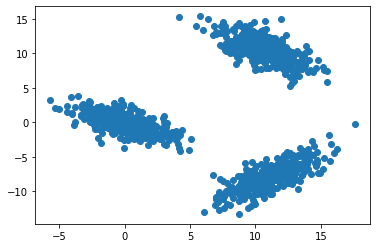

In [ ]:
plt.scatter(dataset['X1'],dataset['X2'])

In [ ]:
def separate_by_class(dataset):
	separated = dict()
	for i in range(len(dataset)):
		vector = dataset[i]
		class_value = vector[-1]
		if (class_value not in separated):
			separated[class_value] = list()
		separated[class_value].append(vector)
	return separated

In [ ]:
Data1 = separate_by_class(Data)

In [ ]:
Data1

{1.0: [array([-0.9285 , -0.71995,  1.     ]),
  array([-3.2746,  2.4436,  1.    ]),
  array([0.50871, 0.64457, 1.     ]),
  array([ 0.59212, -1.3693 ,  1.     ]),
  array([ 2.1432, -2.6496,  1.    ]),
  array([-1.4012 ,  0.73143,  1.     ]),
  array([-1.0752 , -0.94375,  1.     ]),
  array([-0.26652,  0.79366,  1.     ]),
  array([-1.5436 , -0.10377,  1.     ]),
  array([-0.93854, -1.5054 ,  1.     ]),
  array([0.30636, 1.3604 , 1.     ]),
  array([-0.91351, -0.29203,  1.     ]),
  array([0.4619 , 0.82578, 1.     ]),
  array([-2.7482 ,  0.86637,  1.     ]),
  array([-1.9228 ,  0.42743,  1.     ]),
  array([ 1.7649, -1.7965,  1.    ]),
  array([-4.4297,  2.3129,  1.    ]),
  array([-1.1589 , -0.60859,  1.     ]),
  array([-2.0733,  1.956 ,  1.    ]),
  array([-0.76247,  2.0085 ,  1.     ]),
  array([-2.4187,  1.9154,  1.    ]),
  array([ 0.080135, -2.4906  ,  1.      ]),
  array([-0.86699, -0.74075,  1.     ]),
  array([-1.6377 , -0.70615,  1.     ]),
  array([-0.50767,  0.99647,  1.   

In [ ]:
meu = []
for i in Data1:
  M = []
  for j in range(len(Data1[i][0])-1):
    Data = np.asarray(Data1[i])
    M.append(np.sum(Data[:][:,j])/len(Data[:][:,j]))
  meu.append(M)

In [ ]:
meu

[[0.11049909314285711, -0.14947141769142858],
 [10.665218000000001, 10.511363999999999],
 [11.247643714285713, -7.815170028571429]]

In [ ]:
Covarience_Matrix = []
for i in Data1:
  Data = np.asarray(Data1[i])
  Covarience_Matrix.append(np.cov(Data[:][:,0],Data[:][:,1]))


In [ ]:
Covarience_Matrix

[array([[ 4.00120544, -1.97041452],
        [-1.97041452,  2.2065844 ]]), array([[ 3.4193959 , -2.30650294],
        [-2.30650294,  3.42358592]]), array([[3.81993808, 2.86737734],
        [2.86737734, 3.82415238]])]

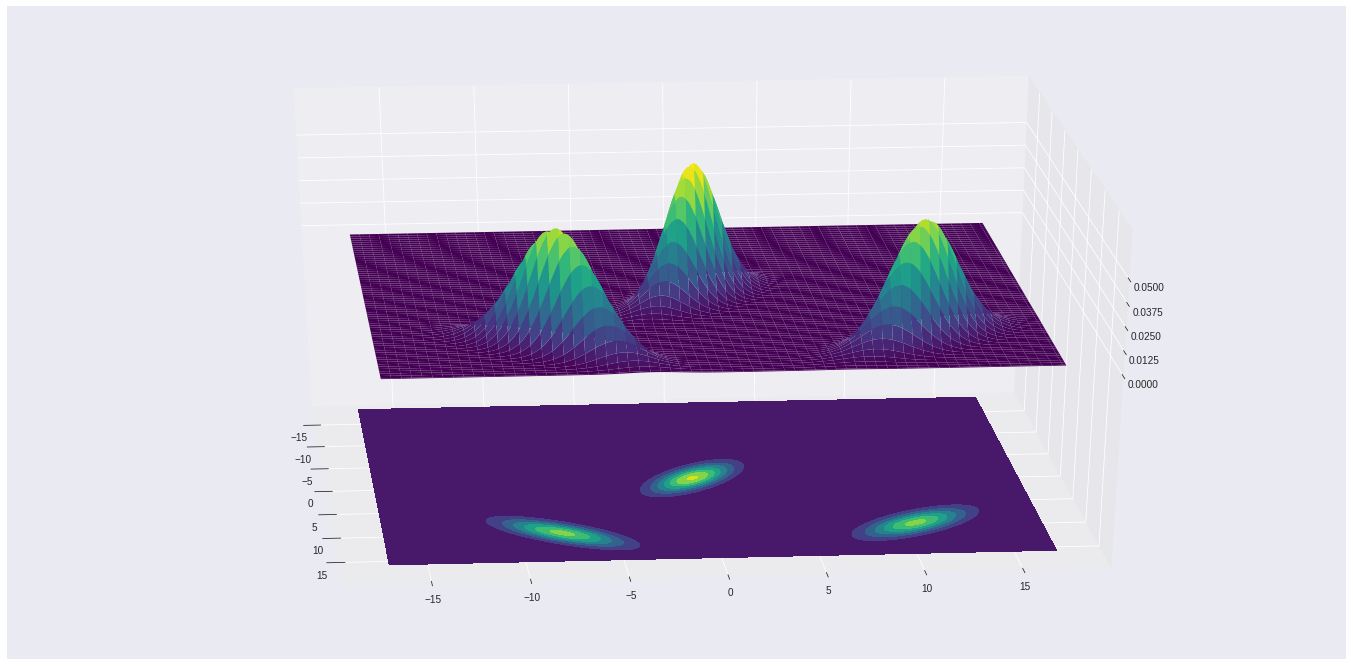

In [ ]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Mean vector and covariance matrix
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])

# Our 2-dimensional distribution will be over variables X and Y
     
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
mu = np.asarray(meu[0])
Sigma = np.asarray(Covarience_Matrix[0])
Z = multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[2])
Sigma = np.asarray(Covarience_Matrix[2])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
# Create a surface plot and projected filled contour plot under it.
fig = plt.figure(figsize=(24,12))
ax = fig.gca(projection='3d')
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis)

cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.1, cmap=cm.viridis)

# Adjust the limits, ticks and view angle
ax.set_zlim(-0.1,np.max(Z))
ax.set_zticks(np.linspace(0,0.05,5))
ax.view_init(27,-5)

plt.show()

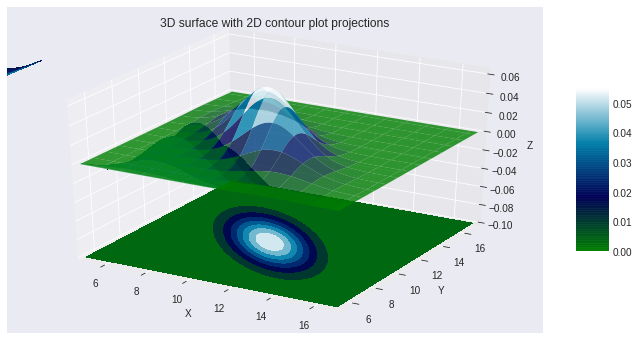

In [ ]:
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])

# Our 2-dimensional distribution will be over variables X and Y

sigma_1, sigma_2 = Covarience_Matrix[1][0,0], Covarience_Matrix[1][1,1]
     
X = np.linspace(5,17 , num=100)
Y = np.linspace(5, 17, num=100)
X, Y = np.meshgrid(X, Y)

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
Z = multivariate_gaussian(pos, mu, Sigma)
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(X, Y, Z, rstride=8, cstride=8, alpha=0.8, cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.1, cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='x', offset=-5,cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='y', offset=5, cmap=cm.ocean)


fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


ax.set_xlabel('X')
ax.set_xlim(5, 17)
ax.set_ylabel('Y')
ax.set_ylim(5, 17)
ax.set_zlabel('Z')
ax.set_zlim(-0.1, np.max(Z))
ax.set_title('3D surface with 2D contour plot projections')


plt.show()